# Train GRU All-States Seq2Seq with Non-Overlapping Test Evaluation

This follow-up notebook tests using all recurrent hidden states instead of only the final hidden state. It saves outputs to `results_allstates/`, `figures_allstates/`, and `models_allstates/`.

In [1]:
from pathlib import Path
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
try:
    print("MPS available:", torch.backends.mps.is_available())
except Exception:
    print("MPS available: False")

PyTorch version: 2.10.0
CUDA available: False
MPS available: True


In [2]:
SEED = 63
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

# Change this to "baseline" or "physics" and run the notebook from the top.
FEATURE_SET = "physics"   # options: "baseline", "physics"

INPUT_LENGTH = 50
PREDICTION_HORIZON = 50
STRIDE = 5
TEST_STRIDE = PREDICTION_HORIZON

BATCH_SIZE = 256
EPOCHS = 50
LEARNING_RATE = 1e-3
PATIENCE = 8
WEIGHT_DECAY = 1e-5

PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results_allstates")
FIGURES_DIR = Path("../figures_allstates")
MODELS_DIR = Path("../models_allstates")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

NPZ_PATH = PROCESSED_DIR / f"seq2seq_{FEATURE_SET}_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}.npz"
SCALER_PATH = PROCESSED_DIR / f"seq2seq_{FEATURE_SET}_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}_scaler.json"

print("NPZ path:", NPZ_PATH)
print("Scaler path:", SCALER_PATH)

Using device: mps
NPZ path: ../data/processed/seq2seq_physics_L50_H50_S5.npz
Scaler path: ../data/processed/seq2seq_physics_L50_H50_S5_scaler.json


In [3]:
data = np.load(NPZ_PATH)

X_train = data["X_train"]
Y_train = data["Y_train"]
X_val = data["X_val"]
Y_val = data["Y_val"]
X_test = data["X_test"]
Y_test = data["Y_test"]

with open(SCALER_PATH, "r") as f:
    scaler = json.load(f)

input_cols = scaler["input_cols"]
output_cols = scaler["output_cols"]
y_mean = np.array(scaler["y_mean"], dtype=np.float32)
y_std = np.array(scaler["y_std"], dtype=np.float32)

print("Input columns:", input_cols)
print("Output columns:", output_cols)
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val:", X_val.shape, "Y_val:", Y_val.shape)
print("X_test:", X_test.shape, "Y_test:", Y_test.shape)

input_dim = X_train.shape[-1]
output_dim = Y_train.shape[-1]

Input columns: ['Current [A]', 'Terminal voltage [V]', 'Cumulative charge [A.s]', 'Sqrt cumulative charge [sqrt(A.s)]']
Output columns: ['SEI growth rate [nm/s]', 'Negative SEI thickness [nm]', 'Cell temperature [K]']
X_train: (233957, 50, 4) Y_train: (233957, 50, 3)
X_val: (56993, 50, 4) Y_val: (56993, 50, 3)
X_test: (49033, 50, 4) Y_test: (49033, 50, 3)


In [4]:
class Seq2SeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_loader = DataLoader(Seq2SeqDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(Seq2SeqDataset(X_val, Y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(Seq2SeqDataset(X_test, Y_test), batch_size=BATCH_SIZE, shuffle=False)

In [5]:
class GRUAllStatesSeq2Seq(nn.Module):
    """GRU direct multi-horizon model using all recurrent hidden states.

    The earlier GRU model used only the final hidden state h_n[-1].
    This version uses the full output sequence from the GRU:
        s_1, s_2, ..., s_L
    The hidden states are flattened and passed to the feedforward prediction head.
    This lets the prediction head use information from the whole encoded input trajectory.
    """

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, input_length, horizon, dropout=0.2):
        super().__init__()
        self.output_dim = output_dim
        self.horizon = horizon
        self.input_length = input_length
        self.hidden_dim = hidden_dim

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.Linear(input_length * hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, horizon * output_dim),
        )

    def forward(self, x):
        out_seq, _ = self.gru(x)                 # (batch, L, hidden_dim)
        flat = out_seq.reshape(out_seq.size(0), -1)  # (batch, L * hidden_dim)
        out = self.head(flat)                    # (batch, H * output_dim)
        out = out.view(-1, self.horizon, self.output_dim)
        return out

model_name = f"gru_allstates_{FEATURE_SET}_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}"
model = GRUAllStatesSeq2Seq(
    input_dim=input_dim,
    hidden_dim=128,
    num_layers=2,
    output_dim=output_dim,
    input_length=INPUT_LENGTH,
    horizon=PREDICTION_HORIZON,
    dropout=0.2,
).to(device)
print(model)


GRUAllStatesSeq2Seq(
  (gru): GRU(4, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=6400, out_features=128, bias=True)
    (1): Tanh()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=150, bias=True)
  )
)


In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_count = 0
    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        if is_train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(is_train):
            preds = model(X_batch)
            loss = criterion(preds, Y_batch)
            if is_train:
                loss.backward()
                optimizer.step()
        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size
    return total_loss / total_count

@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds_all = []
    targets_all = []
    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        preds_all.append(preds)
        targets_all.append(Y_batch.numpy())
    return np.concatenate(preds_all, axis=0), np.concatenate(targets_all, axis=0)

def inverse_transform_y(y_scaled):
    return y_scaled * y_std.reshape(1, 1, -1) + y_mean.reshape(1, 1, -1)

def safe_name(text):
    return (
        text.replace(" ", "_")
        .replace("[", "")
        .replace("]", "")
        .replace("/", "_per_")
        .replace(".", "")
        .replace("(", "")
        .replace(")", "")
    )

In [7]:
def compute_metrics(y_true, y_pred, output_cols):
    rows = []
    eps = 1e-12
    for i, col in enumerate(output_cols):
        yt = y_true[:, :, i].reshape(-1)
        yp = y_pred[:, :, i].reshape(-1)
        error = yp - yt
        mse = np.mean(error ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(error))
        true_std = np.std(yt)
        true_mean_abs = np.mean(np.abs(yt))
        nmae_std = mae / (true_std + eps)
        nrmse_std = rmse / (true_std + eps)
        relative_mae = mae / (true_mean_abs + eps)
        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - np.mean(yt)) ** 2)
        r2 = 1 - ss_res / (ss_tot + eps)
        rows.append({
            "output": col,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "NMAE_std": nmae_std,
            "NRMSE_std": nrmse_std,
            "Relative_MAE_mean_abs": relative_mae,
            "R2": r2,
            "true_mean_abs": true_mean_abs,
            "true_std": true_std,
        })
    return pd.DataFrame(rows)

def physical_violation_check(pred, output_cols):
    rows = []
    checked_outputs = [
        "SEI growth rate [nm/s]",
        "Negative SEI thickness [nm]",
        "Cell temperature [K]",
    ]
    for col in checked_outputs:
        if col not in output_cols:
            continue
        idx = output_cols.index(col)
        values = pred[:, :, idx]
        total_count = values.size
        negative_count = np.sum(values < 0)
        rows.append({
            "output": col,
            "negative_count": int(negative_count),
            "total_count": int(total_count),
            "negative_percent": 100 * negative_count / total_count,
            "minimum_prediction": float(np.min(values)),
        })
    return pd.DataFrame(rows)

def horizon_wise_nmae(y_true, y_pred, output_cols):
    rows = []
    eps = 1e-12
    for i, col in enumerate(output_cols):
        true_std = np.std(y_true[:, :, i].reshape(-1))
        for h in range(y_true.shape[1]):
            mae = np.mean(np.abs(y_true[:, h, i] - y_pred[:, h, i]))
            rows.append({"horizon_step": h + 1, "output": col, "NMAE_std": mae / (true_std + eps)})
    return pd.DataFrame(rows)

## Train model

In [8]:
best_val_loss = float("inf")
epochs_without_improvement = 0
history = []
best_model_path = MODELS_DIR / f"{model_name}_best.pt"

start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss = run_epoch(model, val_loader, optimizer=None)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "lr": current_lr})
    print(f"Epoch {epoch:03d} | train={train_loss:.6f} | val={val_loss:.6f} | lr={current_lr:.2e}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "best_val_loss": best_val_loss,
            "feature_set": FEATURE_SET,
            "input_cols": input_cols,
            "output_cols": output_cols,
        }, best_model_path)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

training_time = time.time() - start_time
print("Best validation loss:", best_val_loss)
print(f"Training time: {training_time:.2f} seconds")

history_df = pd.DataFrame(history)
history_path = RESULTS_DIR / f"{model_name}_history.csv"
history_df.to_csv(history_path, index=False)
print("Saved history:", history_path.resolve())

Epoch 001 | train=0.098552 | val=0.069113 | lr=1.00e-03
Epoch 002 | train=0.048197 | val=0.051879 | lr=1.00e-03
Epoch 003 | train=0.037388 | val=0.032980 | lr=1.00e-03
Epoch 004 | train=0.032119 | val=0.026863 | lr=1.00e-03
Epoch 005 | train=0.025248 | val=0.023133 | lr=1.00e-03
Epoch 006 | train=0.023100 | val=0.030005 | lr=1.00e-03
Epoch 007 | train=0.021233 | val=0.026059 | lr=1.00e-03
Epoch 008 | train=0.020144 | val=0.023674 | lr=1.00e-03
Epoch 009 | train=0.019260 | val=0.029825 | lr=5.00e-04
Epoch 010 | train=0.015527 | val=0.022787 | lr=5.00e-04
Epoch 011 | train=0.015226 | val=0.024070 | lr=5.00e-04
Epoch 012 | train=0.014997 | val=0.018691 | lr=5.00e-04
Epoch 013 | train=0.014767 | val=0.021402 | lr=5.00e-04
Epoch 014 | train=0.014550 | val=0.020242 | lr=5.00e-04
Epoch 015 | train=0.013937 | val=0.020750 | lr=5.00e-04
Epoch 016 | train=0.014195 | val=0.022099 | lr=2.50e-04
Epoch 017 | train=0.012327 | val=0.020974 | lr=2.50e-04
Epoch 018 | train=0.011924 | val=0.023425 | lr=2

## Standard overlapping-window evaluation

In [9]:
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
print("Loaded best model from epoch:", checkpoint["epoch"])

pred_val_scaled, true_val_scaled = predict(model, val_loader)
pred_test_scaled, true_test_scaled = predict(model, test_loader)

pred_val = inverse_transform_y(pred_val_scaled)
true_val = inverse_transform_y(true_val_scaled)
pred_test = inverse_transform_y(pred_test_scaled)
true_test = inverse_transform_y(true_test_scaled)

val_metrics = compute_metrics(true_val, pred_val, output_cols)
val_metrics.insert(0, "split", "val_overlap_stride5")

test_metrics = compute_metrics(true_test, pred_test, output_cols)
test_metrics.insert(0, "split", "test_overlap_stride5")

metrics_df = pd.concat([val_metrics, test_metrics], ignore_index=True)
metrics_path = RESULTS_DIR / f"{model_name}_standard_overlap_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print("Saved standard overlap metrics:", metrics_path.resolve())
display(metrics_df)

violations_df = physical_violation_check(pred_test, output_cols)
violations_df.insert(0, "split", "test_overlap_stride5")
violations_path = RESULTS_DIR / f"{model_name}_standard_overlap_physical_violations.csv"
violations_df.to_csv(violations_path, index=False)
print("Saved standard overlap physical violations:", violations_path.resolve())
display(violations_df)

Loaded best model from epoch: 12
Saved standard overlap metrics: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_allstates/gru_allstates_physics_L50_H50_S5_standard_overlap_metrics.csv


,split,output,MSE,RMSE,MAE,NMAE_std,NRMSE_std,Relative_MAE_mean_abs,R2,true_mean_abs,true_std
0,val_overlap_stride5,SEI growth rate [nm/s],6.163148e-08,0.000248,0.000123,0.061194,0.123487,0.053660,0.984751,0.002293,0.002010
1,val_overlap_stride5,Negative SEI thickness [nm],2.281786e+02,15.105581,10.157953,0.096071,0.142864,0.054525,0.979590,186.300522,105.734329
2,val_overlap_stride5,Cell temperature [K],2.319012e-03,0.048156,0.019613,0.051377,0.126147,0.000066,0.984087,298.089081,0.381747
3,test_overlap_stride5,SEI growth rate [nm/s],4.933773e-07,0.000702,0.000281,0.131603,0.329261,0.114962,0.891587,0.002442,0.002133
4,test_overlap_stride5,Negative SEI thickness [nm],5.734639e+02,23.947107,14.610009,0.163341,0.267731,0.096863,0.928320,150.831879,89.444664
5,test_overlap_stride5,Cell temperature [K],1.165825e-02,0.107973,0.043150,0.098034,0.245306,0.000145,0.939825,298.104492,0.440159


Saved standard overlap physical violations: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_allstates/gru_allstates_physics_L50_H50_S5_standard_overlap_physical_violations.csv


,split,output,negative_count,total_count,negative_percent,minimum_prediction
0,test_overlap_stride5,SEI growth rate [nm/s],7111,2451650,0.290050,-0.000644
1,test_overlap_stride5,Negative SEI thickness [nm],814,2451650,0.033202,-6.953781
2,test_overlap_stride5,Cell temperature [K],0,2451650,0.000000,295.503998


Saved standard horizon NMAE: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_allstates/gru_allstates_physics_L50_H50_S5_standard_overlap_horizon_nmae.csv


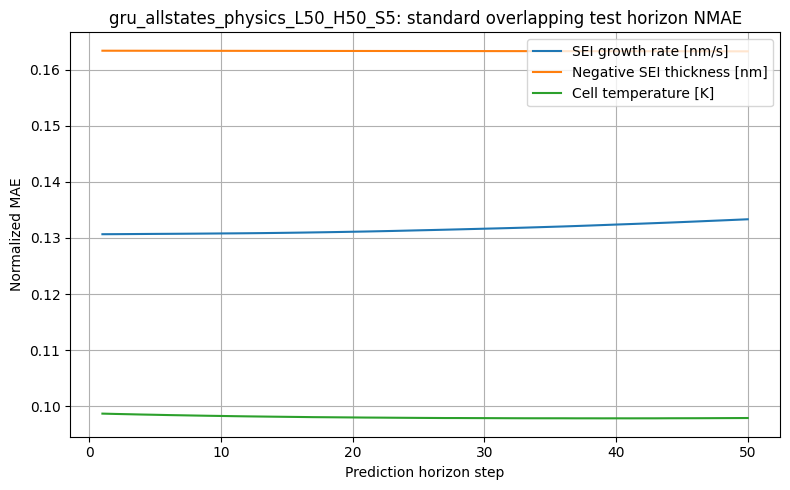

In [10]:
horizon_nmae_df = horizon_wise_nmae(true_test, pred_test, output_cols)
horizon_nmae_path = RESULTS_DIR / f"{model_name}_standard_overlap_horizon_nmae.csv"
horizon_nmae_df.to_csv(horizon_nmae_path, index=False)
print("Saved standard horizon NMAE:", horizon_nmae_path.resolve())

plt.figure(figsize=(8, 5))
for col in output_cols:
    temp = horizon_nmae_df[horizon_nmae_df["output"] == col]
    plt.plot(temp["horizon_step"], temp["NMAE_std"], label=col)
plt.xlabel("Prediction horizon step")
plt.ylabel("Normalized MAE")
plt.title(f"{model_name}: standard overlapping test horizon NMAE")
plt.legend()
plt.grid(True)
plt.tight_layout()
fig_path = FIGURES_DIR / f"{model_name}_standard_overlap_horizon_nmae_all_outputs.png"
plt.savefig(fig_path, dpi=200)
plt.show()

## Non-overlapping test-block evaluation

In [ ]:
# Non-overlapping test-block evaluation.
# Existing test windows were created with STRIDE=5. Since H=50, selecting every 10th
# test window gives approximately non-overlapping forecast blocks.

if TEST_STRIDE % STRIDE != 0:
    raise ValueError("TEST_STRIDE must be divisible by STRIDE for this quick selection method.")

test_stride_factor = TEST_STRIDE // STRIDE
X_test_blocks = X_test[::test_stride_factor]
Y_test_blocks = Y_test[::test_stride_factor]

block_test_loader = DataLoader(
    Seq2SeqDataset(X_test_blocks, Y_test_blocks),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

pred_blocks_scaled, true_blocks_scaled = predict(model, block_test_loader)
pred_blocks = inverse_transform_y(pred_blocks_scaled)
true_blocks = inverse_transform_y(true_blocks_scaled)

print("Original overlapping test windows:", X_test.shape[0])
print("Non-overlapping test windows:", X_test_blocks.shape[0])
print("Selection factor:", test_stride_factor)
print("TEST_STRIDE:", TEST_STRIDE)

nonoverlap_metrics = compute_metrics(true_blocks, pred_blocks, output_cols)
nonoverlap_metrics.insert(0, "split", f"test_nonoverlap_stride{TEST_STRIDE}")
nonoverlap_metrics_path = RESULTS_DIR / f"{model_name}_nonoverlap_test_metrics.csv"
nonoverlap_metrics.to_csv(nonoverlap_metrics_path, index=False)
print("Saved non-overlapping test metrics:", nonoverlap_metrics_path.resolve())
display(nonoverlap_metrics)

nonoverlap_violations = physical_violation_check(pred_blocks, output_cols)
nonoverlap_violations.insert(0, "split", f"test_nonoverlap_stride{TEST_STRIDE}")
nonoverlap_violations_path = RESULTS_DIR / f"{model_name}_nonoverlap_physical_violations.csv"
nonoverlap_violations.to_csv(nonoverlap_violations_path, index=False)
print("Saved non-overlapping physical violations:", nonoverlap_violations_path.resolve())
display(nonoverlap_violations)

Original overlapping test windows: 49033
Non-overlapping test windows: 4904
Selection factor: 10
TEST_STRIDE: 50
Saved non-overlapping test metrics: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_allstates/gru_allstates_physics_L50_H50_S5_nonoverlap_test_metrics.csv


,split,output,MSE,RMSE,MAE,NMAE_std,NRMSE_std,Relative_MAE_mean_abs,R2,true_mean_abs,true_std
0,test_nonoverlap_stride50,SEI growth rate [nm/s],4.918030e-07,0.000701,0.000281,0.131494,0.328728,0.114886,0.891938,0.002442,0.002133
1,test_nonoverlap_stride50,Negative SEI thickness [nm],5.727498e+02,23.932190,14.609223,0.163331,0.267561,0.096863,0.928411,150.823288,89.445717
2,test_nonoverlap_stride50,Cell temperature [K],1.150728e-02,0.107272,0.043057,0.097821,0.243708,0.000144,0.940606,298.104523,0.440165


Saved non-overlapping physical violations: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_allstates/gru_allstates_physics_L50_H50_S5_nonoverlap_physical_violations.csv


,split,output,negative_count,total_count,negative_percent,minimum_prediction
0,test_nonoverlap_stride50,SEI growth rate [nm/s],695,245200,0.283442,-0.000280
1,test_nonoverlap_stride50,Negative SEI thickness [nm],31,245200,0.012643,-0.319138
2,test_nonoverlap_stride50,Cell temperature [K],0,245200,0.000000,295.504089


Split points: [0, 117400, 233250, 245200]
Total flattened length: 245200


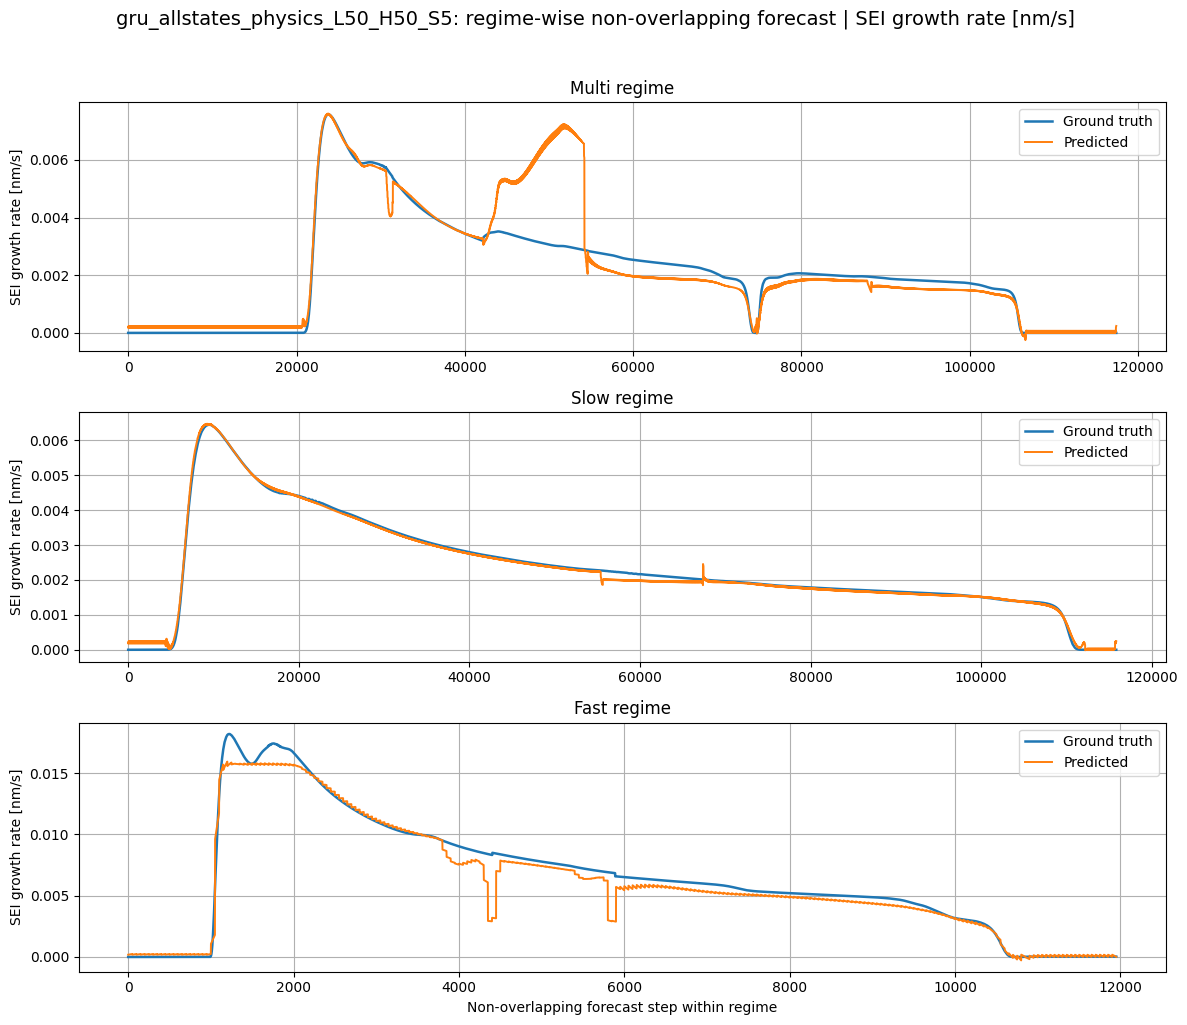

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/gru_allstates_physics_L50_H50_S5_regimewise_nonoverlap_SEI_growth_rate_nm_per_s.png


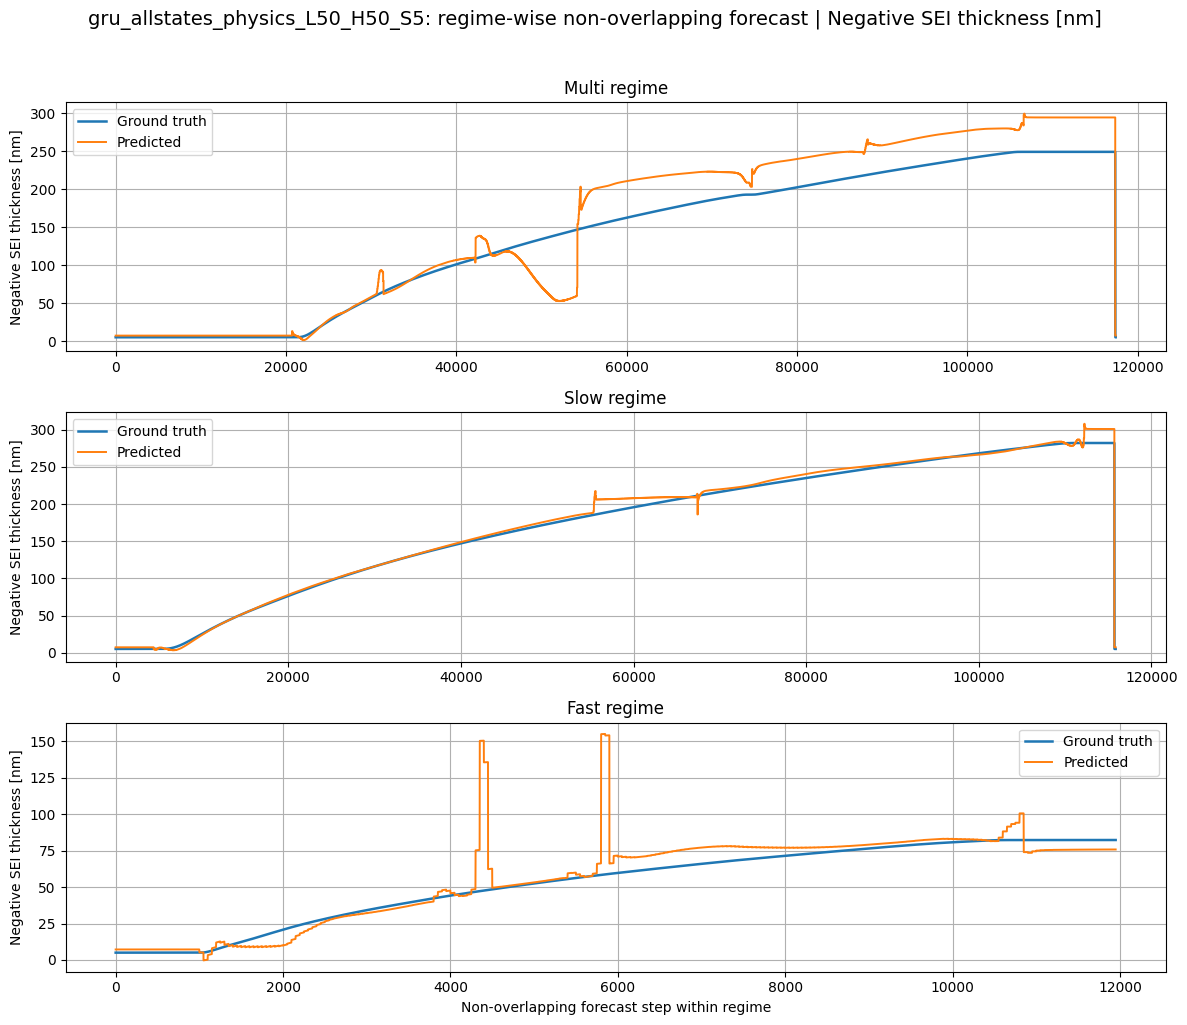

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/gru_allstates_physics_L50_H50_S5_regimewise_nonoverlap_Negative_SEI_thickness_nm.png


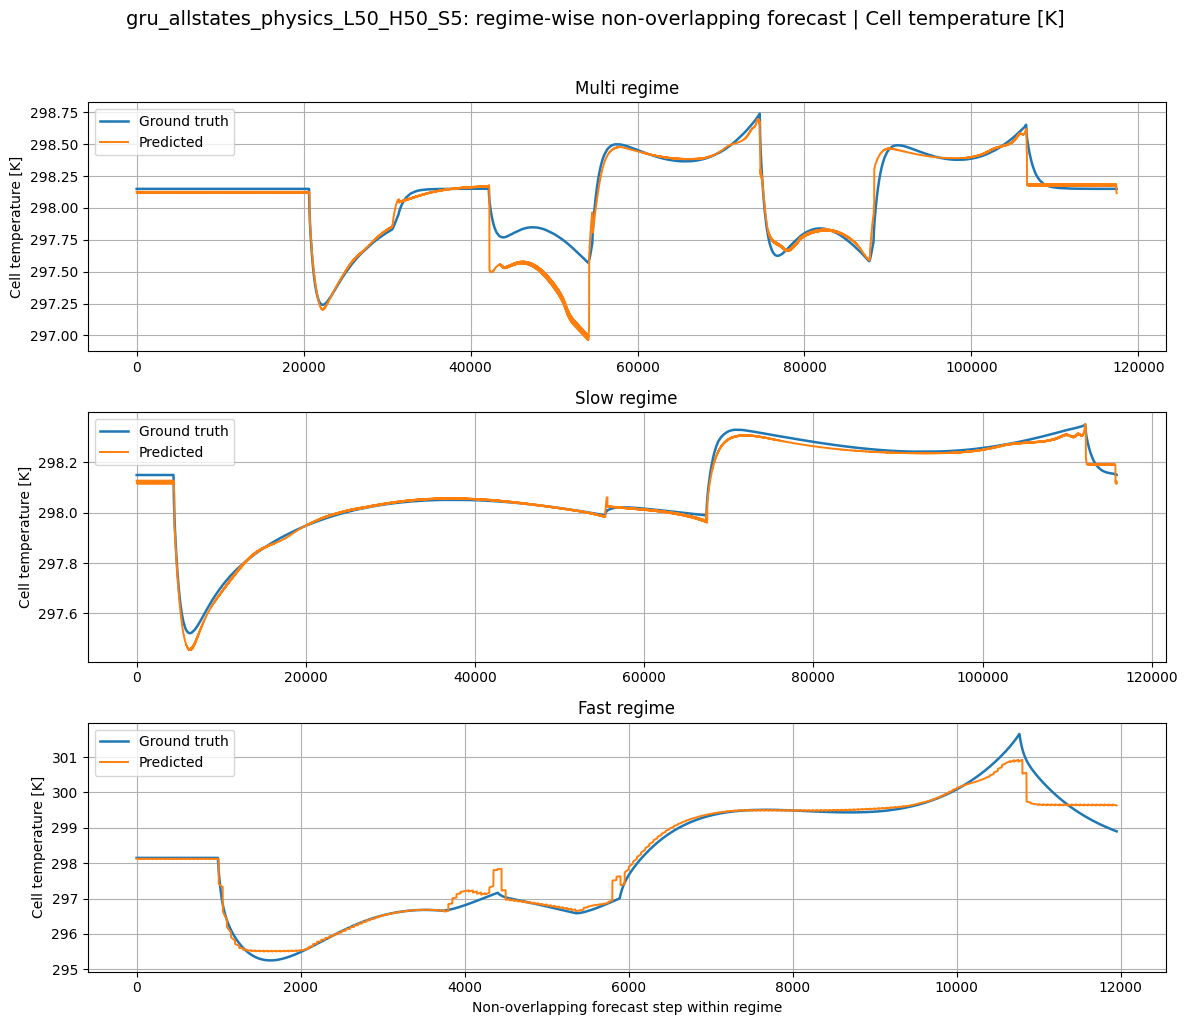

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_allstates/gru_allstates_physics_L50_H50_S5_regimewise_nonoverlap_Cell_temperature_K.png


In [ ]:
# Regime-wise non-overlapping forecast plots for ALL targets
# One figure per target, with 3 subplots:
# Multi -> Slow -> Fast

true_total = true_blocks.reshape(-1, true_blocks.shape[-1])
pred_total = pred_blocks.reshape(-1, pred_blocks.shape[-1])

total_len = min(len(true_total), len(pred_total))

regime_info = [
    ("Multi", 117404),
    ("Slow", 115884),
    ("Fast", 12173),
]

HORIZON = 50

split_points = [0]
for regime_name, rows in regime_info:
    n_seq = rows // HORIZON
    regime_len = n_seq * HORIZON
    split_points.append(split_points[-1] + regime_len)

# Fix possible mismatch caused by dropped incomplete windows
split_points[-1] = total_len

print("Split points:", split_points)
print("Total flattened length:", total_len)

for i, col in enumerate(output_cols):

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

    for r, (regime_name, rows) in enumerate(regime_info):

        start = split_points[r]
        end = split_points[r + 1]

        y_true_segment = true_total[start:end, i]
        y_pred_segment = pred_total[start:end, i]

        steps = np.arange(len(y_true_segment))

        axes[r].plot(
            steps,
            y_true_segment,
            label="Ground truth",
            linewidth=1.8
        )

        axes[r].plot(
            steps,
            y_pred_segment,
            label="Predicted",
            linewidth=1.4
        )

        axes[r].set_title(f"{regime_name} regime")
        axes[r].set_ylabel(col)
        axes[r].grid(True)
        axes[r].legend()

    axes[-1].set_xlabel("Non-overlapping forecast step within regime")

    fig.suptitle(
        f"{model_name}: regime-wise non-overlapping forecast | {col}",
        fontsize=14,
        y=1.02
    )

    plt.tight_layout()

    fig_path = FIGURES_DIR / f"{model_name}_regimewise_nonoverlap_{safe_name(col)}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path.resolve())

Median non-overlap block index based on SEI thickness MAE: 3745


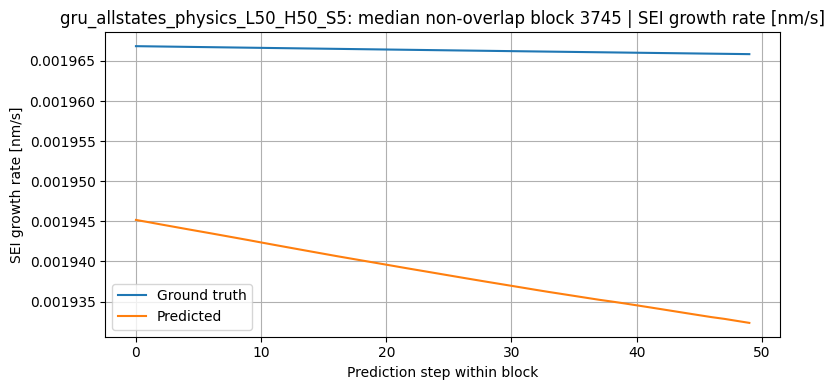

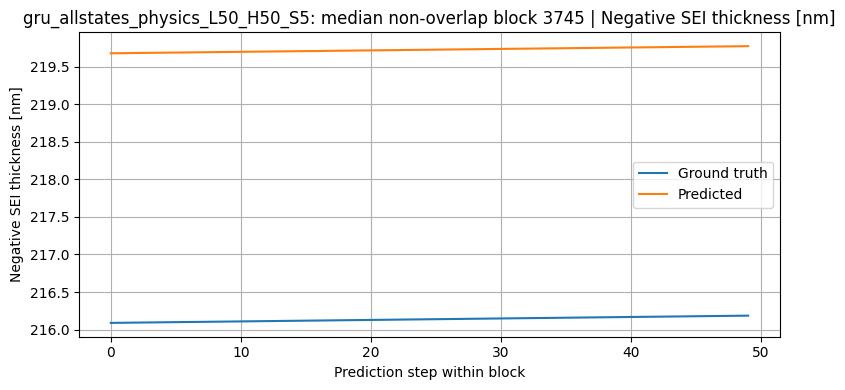

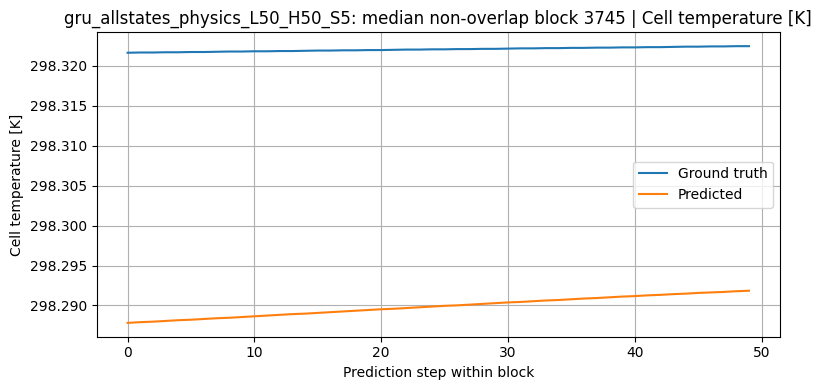

In [13]:
# Representative median non-overlap block plot.
# This helps inspect a typical forecast block without showing too many figures.

sei_idx = output_cols.index("Negative SEI thickness [nm]") if "Negative SEI thickness [nm]" in output_cols else 0
block_mae = np.mean(np.abs(true_blocks[:, :, sei_idx] - pred_blocks[:, :, sei_idx]), axis=1)
median_block_idx = int(np.argsort(block_mae)[len(block_mae) // 2])
print("Median non-overlap block index based on SEI thickness MAE:", median_block_idx)

for i, col in enumerate(output_cols):
    plt.figure(figsize=(8, 4))
    plt.plot(true_blocks[median_block_idx, :, i], label="Ground truth")
    plt.plot(pred_blocks[median_block_idx, :, i], label="Predicted")
    plt.xlabel("Prediction step within block")
    plt.ylabel(col)
    plt.title(f"{model_name}: median non-overlap block {median_block_idx} | {col}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    fig_path = FIGURES_DIR / f"{model_name}_nonoverlap_median_block_{median_block_idx}_{safe_name(col)}.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()